# Conversational Analysis

This notebook contains code to investigate and analyze the conversational building qualities of the PSC:Expresso dataset

In [2]:
#
#   CHANGE THIS
#
base_dir = "C:/Users/jackm/Documents/Github Projects/ms-capstone-TTS-natlang-styleprompts/src/data/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented"

In [3]:
from datasets import load_dataset
import pandas as pd

# Load the entire dataset
# dataset =
# load_dataset("ajd12342/paraspeechcaps")

# Load specific splits of the dataset
# train_scaled = load_dataset("ajd12342/paraspeechcaps", split="train_scaled") #Only has EMilia files
train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

dfs = [
    # train_scaled.to_pandas(),
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
df = pd.concat(dfs, ignore_index=True)

# filter out VoxCeleb
df = df[df["source"] == "expresso"]
df = df[df["relative_audio_path"].str.contains("conversational_vad_segmented")]

c:\Users\jackm\miniconda3\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# extract columsn for conversation building helpers

import re

def parse_start_time(filename):
    match = re.search(r'_segment_(\d+\.\d+)_', filename)
    return float(match.group(1)) if match else float('inf')

def parse_end_time(filename):
    match = re.search(r'_segment_\d+\.\d+_(\d+\.\d+)\.wav', filename)
    return float(match.group(1)) if match else float('inf')

df['speakers'] = df['relative_audio_path'].str.extract(r'(ex\d+-ex\d+)')
df['high_lvl_style'] = df['relative_audio_path'].str.extract(r'ex\d+-ex\d+/([\w-]+)/')
df['conv_num'] = df['relative_audio_path'].str.extract(r'_(\d+)_channel')
df['start_time'] = df['relative_audio_path'].apply(parse_start_time)
df['end_time'] = df['relative_audio_path'].apply(parse_end_time)


print(df['high_lvl_style'].unique())

<ArrowStringArray>
[      'disgusted',        'laughing',            'calm',            'fast',
      'enunciated', 'sad-sympathetic',        'confused',          'desire',
           'angry',       'projected',       'sarcastic',           'happy',
 'sympathetic-sad',         'whisper',         'fearful',          'sleepy',
             'awe',           'bored']
Length: 18, dtype: str


In [5]:
# Build conv_id from structured columns
df['_conv_id'] = df['speakers'] + '_' + df['high_lvl_style'] + '_' + df['conv_num']

df = df.sort_values(['_conv_id', 'start_time']).reset_index(drop=True)

df['turn_index'] = df.groupby('_conv_id').cumcount()
df['prev_filename'] = df.groupby('_conv_id')['relative_audio_path'].shift(1)




In [ ]:
pd.set_option('display.max_colwidth', 50)
df

In [7]:
# check for files that are missing from conversations, skipping style folders that arent represented at all
import os

valid_styles = set(df['high_lvl_style'].unique())

wav_files = []


for root, dirs, files in os.walk(base_dir):
    # check if this directory is under a valid style folder
    style_match = re.search(r'conversational_vad_segmented/[^/]+/([\w-]+)', root.replace('\\', '/'))
    if style_match and style_match.group(1) not in valid_styles:
        continue
    for file in files:
        if file.endswith('.wav'):
            wav_files.append(os.path.join(root, file))

prefix = base_dir.replace("audio_48khz/conversational_vad_segmented", "")
wav_files_rel = [f.replace('\\', '/').removeprefix(prefix) for f in wav_files]

existing = set(df['relative_audio_path'].values)
missing = [f for f in wav_files_rel if f not in existing]

print(f"Total wav files found: {len(wav_files_rel)}")
print(f"Missing from dataframe: {len(missing)}")


Total wav files found: 12244
Missing from dataframe: 3376


In [8]:
# separate conversations at the missing file, to keep conversations contiguous
df_split = df.copy()
df_split['_is_split_point'] = False

for f in missing:
    match = re.search(r'(ex\d+-ex\d+)_([\w-]+)_(\d+)_channel', f)
    if not match:
        continue
    conv_id = f"{match.group(1)}_{match.group(2)}_{match.group(3)}"
    start = parse_start_time(f)
    if start is not None:
        # only mark the first row at or after the missing file's start time
        idx = df_split[(df_split['_conv_id'] == conv_id) & (df_split['start_time'] >= start)].index
        if len(idx) > 0:
            df_split.loc[idx[0], '_is_split_point'] = True

df_split['_conv_id_split'] = df_split['_conv_id'] + '_part' + df_split.groupby('_conv_id')['_is_split_point'].transform(lambda x: x.cumsum().astype(str))

df_split['turn_index'] = df_split.groupby('_conv_id_split').cumcount()
df_split['prev_filename'] = df_split.groupby('_conv_id_split')['relative_audio_path'].shift(1)

print(f"Original conversations: {df_split['_conv_id'].nunique()}")
print(f"Split conversations: {df_split['_conv_id_split'].nunique()}")

Original conversations: 242
Split conversations: 2311


In [9]:
# df_split

### visualize conversation length after and after split

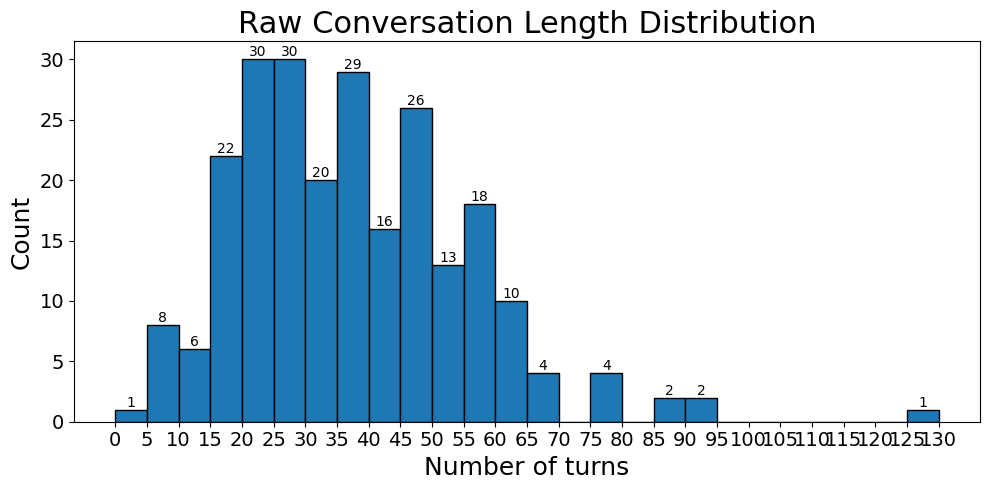

Mean: 36.9, Median: 35, Min: 3, Max: 127


In [ ]:
import matplotlib.pyplot as plt

before = df.groupby('_conv_id')['turn_index'].max() + 1
max_turns = int(after.max())

fig, ax = plt.subplots(figsize=(10, 5))

bins = list(range(0, max_turns + 6, 5))
ax.hist(before, bins=bins, edgecolor='black')
ax.set_title('Raw Conversation Length Distribution', fontsize=22)
ax.set_xlabel('Number of turns', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_xticks(bins)
ax.tick_params(axis='both', labelsize=14)

for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {before.mean():.1f}, Median: {before.median():.0f}, Min: {before.min()}, Max: {before.max()}")

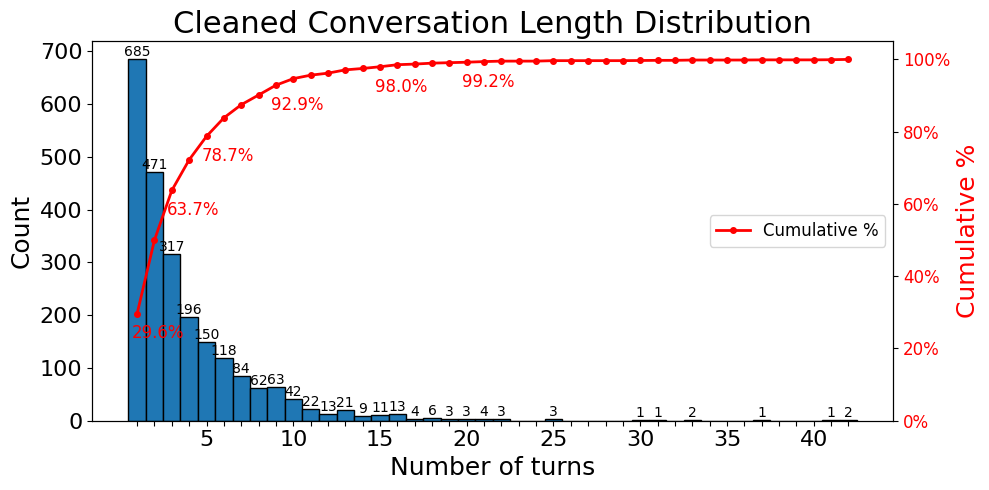

Mean: 3.8, Median: 2, Min: 1, Max: 42


In [17]:
# after split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_df = pd.read_parquet("../data_TEMP/merged_PSC_StyleTalk_CLEANED.parquet")
_df = _df[_df["source"] == "expresso"]

after = _df.groupby('conv_id_split')['turn_index'].max() + 1
max_turns = int(after.max())

fig, ax = plt.subplots(figsize=(10, 5))

bins = [x - 0.5 for x in range(1, max_turns + 2)]
ax.set_xticks(range(1, max_turns + 1))


counts, edges, patches = ax.hist(after, bins=bins, edgecolor='black')
ax.set_title('Cleaned Conversation Length Distribution', fontsize=22)
ax.set_xlabel('Number of turns', fontsize=18)
ax.set_ylabel('Count', fontsize=18)

ax.set_xticks(range(1, max_turns + 1))
ax.set_xticklabels([str(x) if x % 5 == 0 else '' for x in range(1, max_turns + 1)])

ax.tick_params(axis='both', labelsize=16)

for bar in patches:
    count = int(bar.get_height())
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=10)

# cumulative percentage on secondary axis
ax2 = ax.twinx()
ax2.tick_params(axis='y', labelsize=16, labelcolor='red')
cumulative = np.cumsum(counts) / counts.sum() * 100
bin_midpoints = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges) - 1)]
ax2.plot(bin_midpoints, cumulative, color='red', linewidth=2, marker='o', markersize=4, label='Cumulative %')
ax2.set_ylabel('Cumulative %', fontsize=18, color='red')
ax2.tick_params(axis='y', labelsize=12, labelcolor='red')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
thresholds = {1, 3, 5, 9, 15, 20}
for i, (x, y) in enumerate(zip(bin_midpoints, cumulative)):
    if round(x) in thresholds:
        ax2.text(x - 0.3, y - 3, f'{y:.1f}%', ha='left', va='top', fontsize=12, color='red')

ax2.legend(fontsize=12, loc='center right')

plt.tight_layout()
plt.show()

print(f"Mean: {after.mean():.1f}, Median: {after.median():.0f}, Min: {after.min()}, Max: {after.max()}")


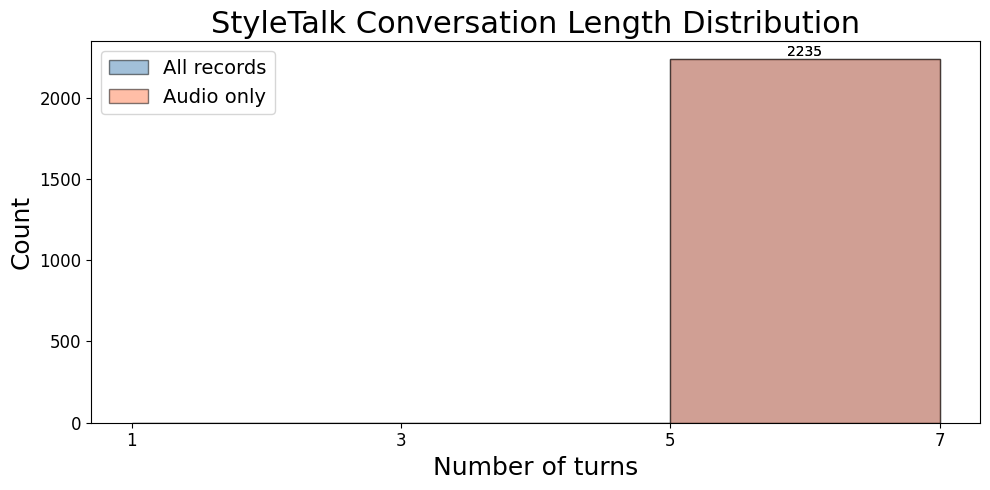

All   — Mean: 5.0, Median: 5, Min: 5, Max: 5
Audio — Mean: 5.0, Median: 5, Min: 5, Max: 5


In [5]:
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet("../data/processed/merged_PSC_StyleTalk_CLEANED.parquet")

st_df = df[df["source"] == "styletalk"]
st_df_audio_only = st_df[st_df["record_type"] == "audio"]

# Get turn counts per conversation
all_turns = st_df.groupby('conv_id')['turn_index'].max() + 1
audio_turns = st_df_audio_only.groupby('conv_id')['turn_index'].max() + 1

max_turns = int(all_turns.max())

fig, ax = plt.subplots(figsize=(10, 5))

bins = list(range(1, max_turns + 3, 2))

ax.hist(all_turns, bins=bins, edgecolor='black', alpha=0.5, color='steelblue', label='All records')
ax.hist(audio_turns, bins=bins, edgecolor='black', alpha=0.5, color='coral', label='Audio only')

ax.set_title('StyleTalk Conversation Length Distribution', fontsize=22)
ax.set_xlabel('Number of turns', fontsize=18)
ax.set_ylabel('Count', fontsize=18)

ax.set_xticks(bins)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14)

for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"All   — Mean: {all_turns.mean():.1f}, Median: {all_turns.median():.0f}, Min: {all_turns.min()}, Max: {all_turns.max()}")
print(f"Audio — Mean: {audio_turns.mean():.1f}, Median: {audio_turns.median():.0f}, Min: {audio_turns.min()}, Max: {audio_turns.max()}")

# PSC + StyleTalk

In [12]:
# output of build_dataset.py
import pandas as pd

proc_df = pd.read_parquet("../data/processed/merged_PSC_StyleTalk_CLEANED.parquet")



In [ ]:
pd.set_option('display.max_colwidth', None)
display(proc_df[proc_df["source"] == "expresso"])

In [ ]:
proc_df.columns

In [14]:
# styletalk results
pd.set_option('display.max_colwidth', None)
display(proc_df[proc_df["source"] == "styletalk"])


,source,relative_audio_path,text_description,transcription,intrinsic_tags,situational_tags,basic_tags,all_tags,speakerid,name,...,utterance_pitch_mean,snr,phonemes,tag_of_interest,conv_id,turn_index,prev_filename,_is_split_point,conv_id_split,record_type
8868,styletalk,book_269/c_2.wav_turn_0,NaN,"I just finished that new book we talked about, and I absolutely loved it!",None,None,None,None,A,NaN,...,NaN,NaN,NaN,None,book_269,0,NaN,None,NaN,text_only
8869,styletalk,book_269/c_2.wav_turn_1,NaN,"Oh, that's fantastic! Do you think I should give it a go?",None,None,None,None,B,NaN,...,NaN,NaN,NaN,None,book_269,1,book_269/c_2.wav_turn_0,None,NaN,text_only
8870,styletalk,book_269/c_2.wav_turn_2,NaN,"Yeah, it had some twists I didn't expect. It's definitely worth the read.",None,None,None,None,A,NaN,...,NaN,NaN,NaN,None,book_269,2,book_269/c_2.wav_turn_1,None,NaN,text_only
8871,styletalk,book_269/c_2.wav,"The speaker speaks at a normal volume, at a normal speed, in a friendly tone.",I'll add it to my list then.,None,None,"[friendly, normal, normal]","[friendly, normal, normal]",B,NaN,...,200.316076,97.604744,NaN,None,book_269,3,book_269/c_2.wav_turn_2,None,NaN,audio
8872,styletalk,book_269/r_2.wav,"The speaker speaks at a fast speed, in a cheerful tone, at a normal volume.","Awesome, you're gonna have to tell me what you think when you're done!",None,None,"[cheerful, fast, normal]","[cheerful, fast, normal]",A,NaN,...,255.323845,38.043037,NaN,None,book_269,4,book_269/c_2.wav,None,NaN,audio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22343,styletalk,music_21/c_0.wav_turn_0,NaN,"I just found this amazing new band, and their music is mind-blowing!",None,None,None,None,A,NaN,...,NaN,NaN,NaN,None,music_21,0,NaN,None,NaN,text_only
22344,styletalk,music_21/c_0.wav_turn_1,NaN,"Oh, that's awesome! What's the name? I totally wanna check them out now!",None,None,None,None,B,NaN,...,NaN,NaN,NaN,None,music_21,1,music_21/c_0.wav_turn_0,None,NaN,text_only
22345,styletalk,music_21/c_0.wav_turn_2,NaN,"They're called The Sonic Waves, and they've got this funky jazz-rock fusion thing going on.",None,None,None,None,A,NaN,...,NaN,NaN,NaN,None,music_21,2,music_21/c_0.wav_turn_1,None,NaN,text_only
22346,styletalk,music_21/c_0.wav,"The speaker speaks at a quiet volume, at a slow speed, in a neutral tone.",I think I've heard about them once before.,None,None,"[neutral, slow, quiet]","[neutral, slow, quiet]",B,NaN,...,238.189698,67.471855,NaN,None,music_21,3,music_21/c_0.wav_turn_2,None,NaN,audio


In [ ]:
# debugging
import pandas as pd
from pathlib import Path

df = pd.read_parquet("../data/processed/merged_PSC_StyleTalk_CLEANED.parquet")
audio_root = Path("../data_TEMP/paraspeechcaps/audio/expresso")

# grab one of the failing rows
row = df.loc[4422]
rel = str(row["relative_audio_path"]).strip()
full = audio_root / rel

print(repr(rel))
print(repr(str(full)))
print("exists:", full.exists())

# also check if resolve() helps
print("resolved exists:", full.resolve().exists())